In [32]:
# !pip install -q pandas numpy matplotlib seaborn textblob itables openpyxl


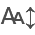

(None,
 Index(['name', 'age', 'gender', 'location', 'year',
        'Were you able to vote in the recent Lok Sabha election?',
        'When did you decide whom to vote for?',
        'What mattered more to you in this election party or candidate?',
        'Which party do you prefer overall?',
        'Did you vote for this party because you really wanted to or due to lack of alternatives?',
        'Whose opinion mattered the most while deciding whom to vote for?',
        'Why were you not able to vote in the recent Lok Sabha election?',
        'How interested were you in the election campaign this time?',
        'Were you or a family member contacted by political parties through phone or social media?',
        'As compared to five years ago, how is the economic condition of your household today?',
        'Rate the effectiveness of the recent government policies (1 to 5)',
        'What is your top issue for this election?',
        'Do you think the government is handling infla

In [33]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from textblob import TextBlob
from itables import init_notebook_mode
from itables import show
init_notebook_mode(all_interactive=True)

# Load the uploaded dataset
file_path = 'final_dummy_political_survey_data.xlsx'
data = pd.read_excel(file_path)

# Preview the data to understand its structure
show(data.head(20)), data.columns


# Trend Analysis

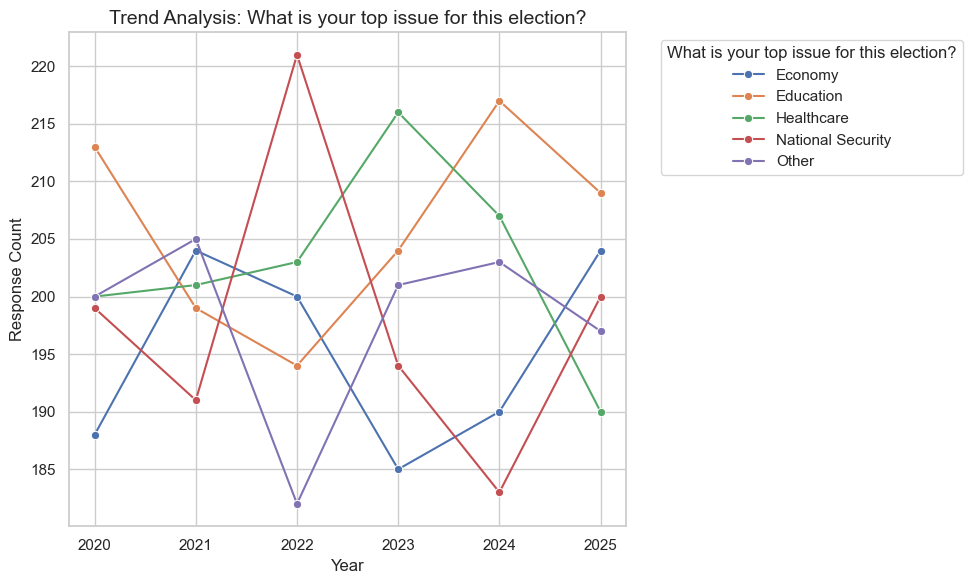

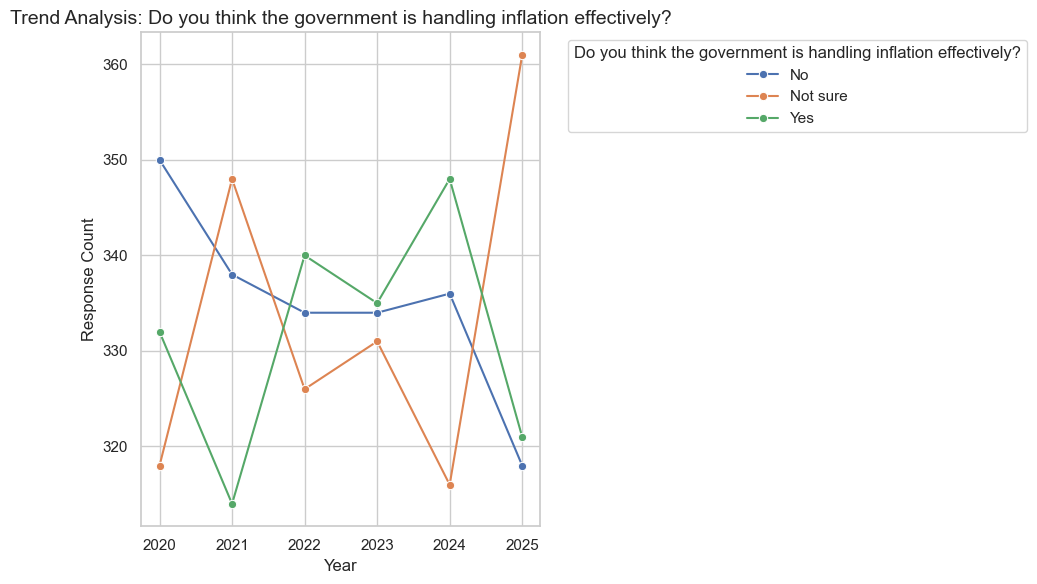

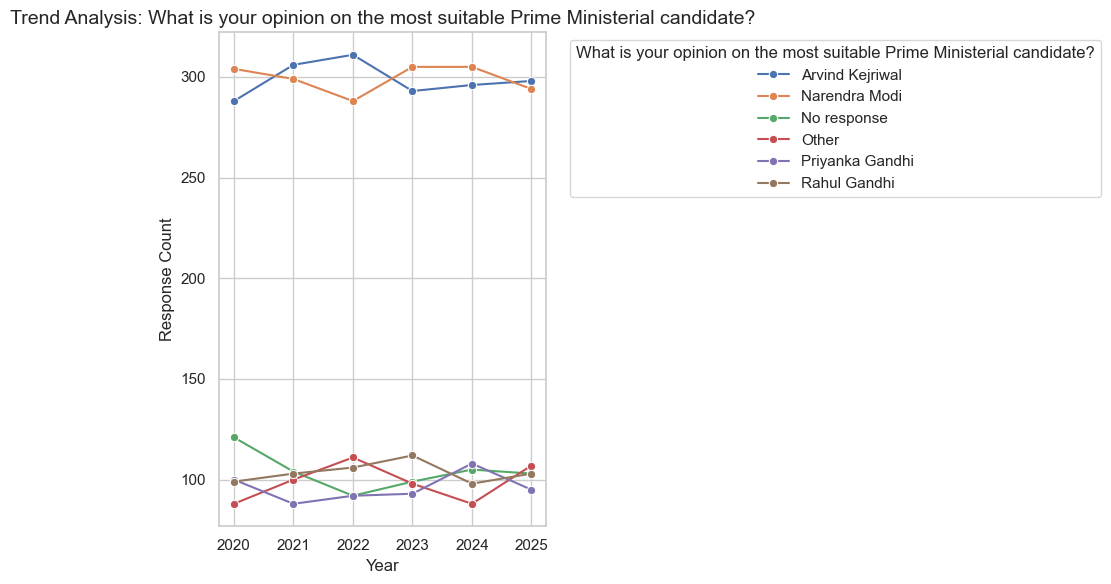

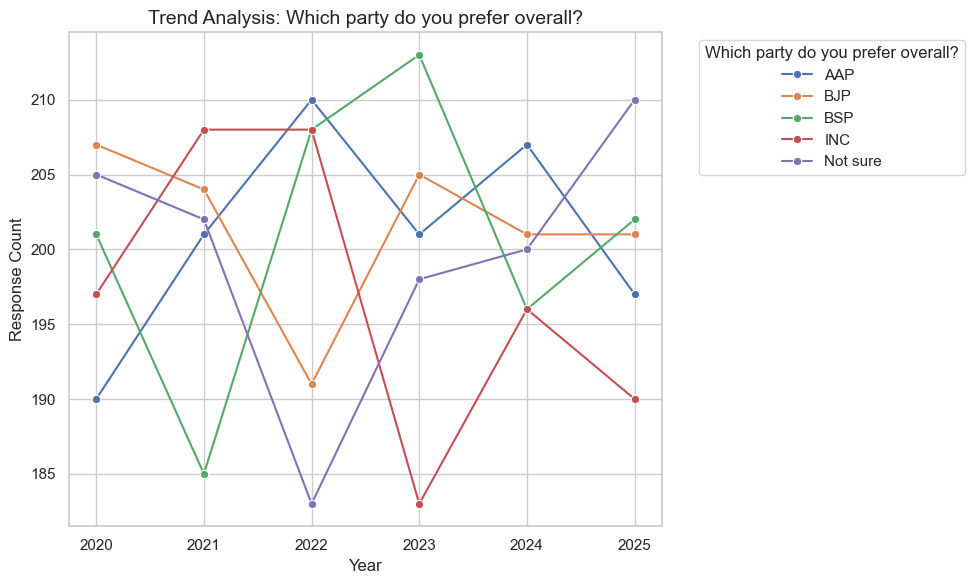

In [34]:
# Prepare data for trend analysis

# Key questions for trend analysis
key_trend_questions = [
    "What is your top issue for this election?",
    'Do you think the government is handling inflation effectively?',
    "What is your opinion on the most suitable Prime Ministerial candidate?",
    "Which party do you prefer overall?"
]

# Plot trends for each key question
# sns.set(style="whitegrid")
for question in key_trend_questions:
    plt.figure(figsize=(10, 6))
    trend_data = data.groupby(["year", question]).size().reset_index(name="count")
    sns.lineplot(data=trend_data, x="year", y="count", hue=question, marker="o")
    plt.title(f"Trend Analysis: {question}", fontsize=14)
    plt.xlabel("Year", fontsize=12)
    plt.ylabel("Response Count", fontsize=12)
    plt.xticks(data['year'].unique())
    plt.legend(title=question, bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()


# Ranking Analysis

In [35]:
# Prepare data for ranked insights
key_ranking_questions = [
    "What is your opinion on the most suitable Prime Ministerial candidate?",
    "Which party do you prefer overall?",
    "What is your top issue for this election?"
]

# Ranked Insights: Aggregate and sort response counts
ranked_insights = {}
for question in key_ranking_questions:
    ranking = data[question].value_counts().reset_index()
    ranking.columns = [question, "count"]
    ranking["rank"] = ranking["count"].rank(method="dense", ascending=False).astype(int)
    ranked_insights[question] = ranking

# Display Ranked Insights
for question, ranking in ranked_insights.items():
    print(f"\nRanked Insights for: {question}\n")
    show(ranking)



Ranked Insights for: What is your opinion on the most suitable Prime Ministerial candidate?




Ranked Insights for: Which party do you prefer overall?




Ranked Insights for: What is your top issue for this election?



# Santiment Analysis

Contextual Santiment Analysis for Catagorical answers (Not free text) (Generally Santiment can be done on free text response/review but here we have option/categorical data)

In [ ]:
# Define contextual weights for sentiment analysis
positive_responses = ["Yes"]
negative_responses = ["No"]
neutral_responses = ["not sure", "no response", "don't know", "did not respond"]

# Adjusted polarity based on contextual weights
def contextual_polarity(text):
    responses = text.split(" | ")  # Split combined text into individual answers
    polarities = []
    for response in responses:
        # Check for explicit responses
        if response in positive_responses:
            polarities.append(1)  # Positive polarity
        elif response in negative_responses:
            polarities.append(-1)  # negative polarity
        elif response.lower() in neutral_responses:
            polarities.append(0)  # Neutral polarity
        else:
            # Default to TextBlob polarity if no explicit match
            polarities.append(TextBlob(response).sentiment.polarity)
    # print(responses)
    # print(polarities)
    # print(sum(polarities) / len(polarities))
    # Return the average polarity for the row
    return sum(polarities) / len(polarities) if polarities else 0


# Combine relevant columns into one for sentiment analysis
textual_columns = [
    # "What is your top issue for this election?",
    # "What is your opinion on the most suitable Prime Ministerial candidate?",
    # "Which party do you prefer overall?",
    "Do you think the government is handling inflation effectively?",
    "Has your trust in the judiciary improved over the last five years?"
]
data["combined_text"] = data[textual_columns].apply(lambda row: " | ".join(row.values.astype(str)), axis=1)

# Apply contextual polarity
data["contextual_polarity"] = data["combined_text"].apply(contextual_polarity)
# print(data["contextual_polarity"])
data["contextual_subjectivity"] = data["combined_text"].apply(lambda text: TextBlob(text).sentiment.subjectivity)

# Summarize adjusted sentiment analysis results
avg_contextual_polarity = data["contextual_polarity"].mean()
avg_subjectivity = data["contextual_subjectivity"].mean()

# Categorize sentiments
data["contextual_sentiment_category"] = data["contextual_polarity"].apply(
    lambda x: "Positive" if x > 0 else ("Negative" if x < 0 else "Neutral")
)

# Count contextual sentiment categories
contextual_sentiment_counts = data["contextual_sentiment_category"].value_counts()

sentiment_summary_contextual = {
    "Average Polarity": avg_contextual_polarity,
    "Average Subjectivity": avg_subjectivity,
    "Sentiment Counts": contextual_sentiment_counts.to_dict(),
}

sentiment_summary_contextual


{'Average Polarity': np.float64(-0.01),
 'Average Subjectivity': np.float64(0.2962962962962963),
 'Sentiment Counts': {'Negative': 2065, 'Positive': 1968, 'Neutral': 1967}}

In [49]:
show(data[["combined_text","contextual_polarity","subjectivity","contextual_sentiment_category"] ])

For Free-text question sentiment analysis

In [ ]:
# Define free-text questions to include in sentiment analysis
free_text_questions = [
    "What do you think is the most important challenge facing the country today?",
    "Share your thoughts on the current government's performance.",
    "What is your opinion on Narendra Modi's leadership?"
]

# Perform sentiment analysis on free-text questions separately
free_text_sentiments = {}
for question in free_text_questions:
    sentiment_data = data[question].dropna()
    sentiment_data = sentiment_data.apply(lambda text: TextBlob(text))
    free_text_sentiments[question] = {
        "Average Polarity": sentiment_data.apply(lambda blob: blob.sentiment.polarity).mean(),
        "Average Subjectivity": sentiment_data.apply(lambda blob: blob.sentiment.subjectivity).mean(),
        "Polarity Distribution": sentiment_data.apply(lambda blob: blob.sentiment.polarity).value_counts().to_dict()
    }


# Summarize final sentiment analysis results
final_sentiment_summary = {
    "Average Polarity": data["final_free_text_polarity"].mean(),
    "Average Subjectivity": data["final_free_text_subjectivity"].mean(),
    "Sentiment Counts": data["final_free_text_polarity"].apply(
        lambda x: "Positive" if x > 0 else ("Negative" if x < 0 else "Neutral")
    ).value_counts().to_dict(),
}

free_text_sentiments, final_sentiment_summary


({'What do you think is the most important challenge facing the country today?': {'Average Polarity': np.float64(0.09046250000000002),
   'Average Subjectivity': np.float64(0.3249425),
   'Polarity Distribution': {0.0: 3586,
    0.5: 908,
    0.45: 322,
    -0.1: 305,
    -0.25: 297,
    -0.2: 295,
    0.375: 287}},
  "Share your thoughts on the current government's performance.": {'Average Polarity': np.float64(0.09568055555555555),
   'Average Subjectivity': np.float64(0.3313722222222223),
   'Polarity Distribution': {0.0: 2059,
    0.2: 916,
    0.03333333333333333: 334,
    0.25: 327,
    0.21666666666666667: 317,
    -0.125: 314,
    -0.30000000000000004: 308,
    0.04999999999999999: 300,
    0.375: 292,
    0.75: 290,
    0.09999999999999998: 278,
    -0.033333333333333326: 265}},
  "What is your opinion on Narendra Modi's leadership?": {'Average Polarity': np.float64(0.0963548611111111),
   'Average Subjectivity': np.float64(0.27417569444444445),
   'Polarity Distribution': {0.

Combined Santiment Overall

In [ ]:
# Combine free-text and categorical sentiment analyses

# Weighting factor (50% for free-text, 50% for categorical adjusted polarity)
weight_categorical = 0.5
weight_free_text = 0.5

# Calculate overall polarity and subjectivity
free_text_polarity = sum([free_text_sentiments[q]["Average Polarity"] for q in free_text_questions]) / len(free_text_questions)
free_text_subjectivity = sum([free_text_sentiments[q]["Average Subjectivity"] for q in free_text_questions]) / len(free_text_questions)

overall_polarity = (weight_categorical * data["contextual_polarity"].mean() + 
                    weight_free_text * free_text_polarity)
overall_subjectivity = (weight_categorical * data["contextual_subjectivity"].mean() + 
                        weight_free_text * free_text_subjectivity)

# Categorize overall sentiment
def categorize_sentiment(polarity):
    if polarity > 0:
        return "Positive"
    elif polarity < 0:
        return "Negative"
    return "Neutral"

overall_sentiment_category = categorize_sentiment(overall_polarity)

# Summary of overall sentiment
overall_sentiment_summary = {
    "Combined Average Polarity": overall_polarity,
    "Combined Average Subjectivity": overall_subjectivity,
    "Overall Sentiment Category": overall_sentiment_category
}

overall_sentiment_summary


{'Combined Average Polarity': np.float64(0.042082986111111116),
 'Combined Average Subjectivity': np.float64(0.30322988425925923),
 'Overall Sentiment Category': 'Positive'}

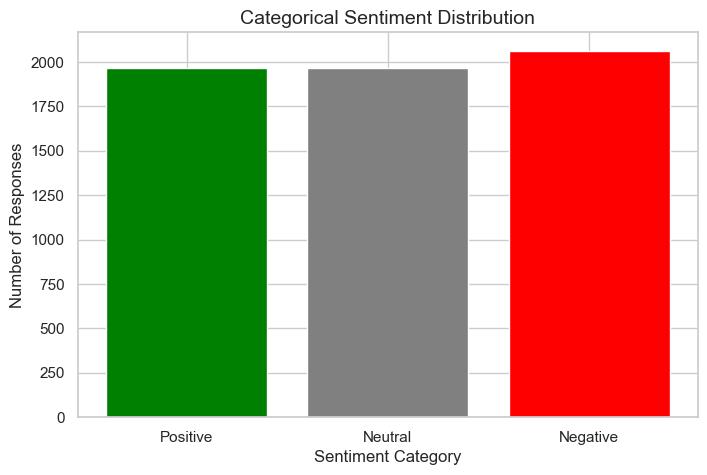

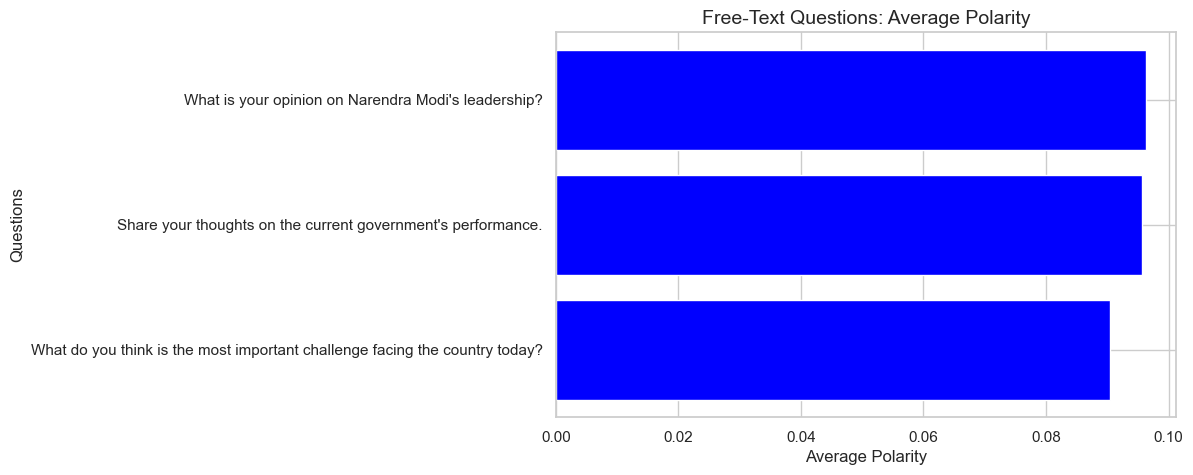

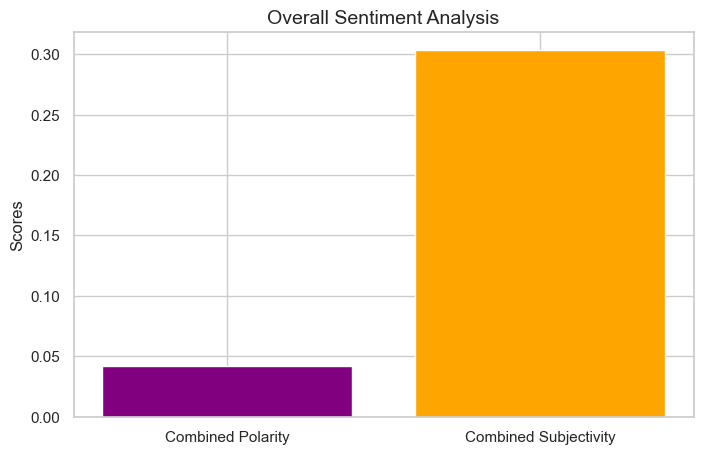

In [54]:
import matplotlib.pyplot as plt

# Prepare data for visualization
sentiment_categories = ["Positive", "Neutral", "Negative"]
sentiment_counts = [
    len(data[data["contextual_sentiment_category"] == "Positive"]),
    len(data[data["contextual_sentiment_category"] == "Neutral"]),
    len(data[data["contextual_sentiment_category"] == "Negative"])
]

# Visualization: Categorical Sentiment Distribution
plt.figure(figsize=(8, 5))
plt.bar(sentiment_categories, sentiment_counts, color=["green", "gray", "red"])
plt.title("Categorical Sentiment Distribution", fontsize=14)
plt.xlabel("Sentiment Category", fontsize=12)
plt.ylabel("Number of Responses", fontsize=12)
plt.show()

# Free-text sentiment analysis visualization
free_text_polarities = [free_text_sentiments[q]["Average Polarity"] for q in free_text_questions]
free_text_labels = free_text_questions

plt.figure(figsize=(8, 5))
plt.barh(free_text_labels, free_text_polarities, color="blue")
plt.title("Free-Text Questions: Average Polarity", fontsize=14)
plt.xlabel("Average Polarity", fontsize=12)
plt.ylabel("Questions", fontsize=12)
plt.show()

# Combined sentiment visualization
combined_data = [overall_polarity, overall_subjectivity]
combined_labels = ["Combined Polarity", "Combined Subjectivity"]

plt.figure(figsize=(8, 5))
plt.bar(combined_labels, combined_data, color=["purple", "orange"])
plt.title("Overall Sentiment Analysis", fontsize=14)
plt.ylabel("Scores", fontsize=12)
plt.show()
